<a href="https://colab.research.google.com/github/raymingchen/ODE/blob/main/DNBM_FEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grid: 100 points, min spacing: 0.00e+00


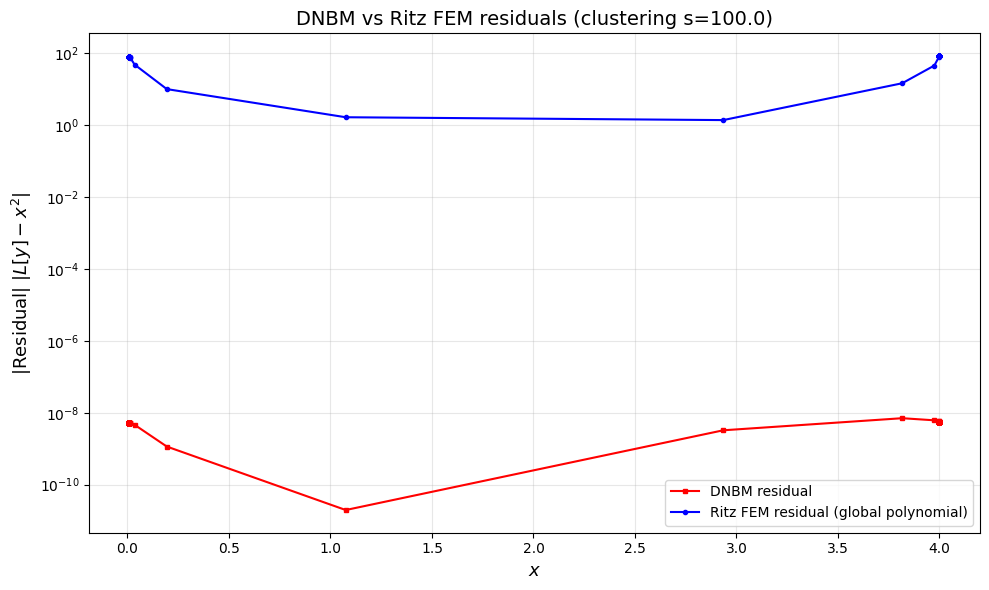

DNBM max |R| (interior) = 7.0661e-09
Ritz FEM max |R| (interior) = 8.4488e+01


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Grid (for plotting and DNBM) – CLUSTERED
# ------------------------------------------------------------
alpha, beta = 0.01, 4.0
Npoints = 100
clustering_strength = 100.0

t = np.linspace(0, 1, Npoints)
if clustering_strength == 0:
    x = alpha + (beta - alpha) * t
else:
    s = clustering_strength
    x = alpha + (beta - alpha) * (np.tanh(s*(t - 0.5)) / np.tanh(s/2) + 1.0) / 2.0
x[0]  = alpha
x[-1] = beta
n = len(x)
print(f"Grid: {n} points, min spacing: {np.min(np.diff(x)):.2e}")

# ------------------------------------------------------------
# 2. Polynomial utilities (exact integration)
# ------------------------------------------------------------
def poly_mul(p, q):
    res = np.zeros(len(p) + len(q) - 1)
    for i, pi in enumerate(p):
        for j, qj in enumerate(q):
            res[i+j] += pi * qj
    return res

def poly_int(p, a, b):
    ant = np.zeros(len(p) + 1)
    for i, c in enumerate(p):
        ant[i+1] = c / (i+1)
    def eval_poly(coeff, xv):
        return np.polyval(coeff[::-1], xv)
    return eval_poly(ant, b) - eval_poly(ant, a)

# ------------------------------------------------------------
# 3. DNBM Basis (your original code)
# ------------------------------------------------------------
D = np.array([[(xi - xj)**4 for xj in x] for xi in x])
D_inv = np.linalg.pinv(D, rcond=1e-8)

alpha_coeff = np.zeros((n, 5))
beta_coeff  = np.zeros((n, 4))
gamma_coeff = np.zeros((n, 3))

for i in range(n):
    for j in range(n):
        xj = x[j]
        poly4 = np.array([xj**4, -4*xj**3, 6*xj**2, -4*xj, 1.0])
        poly3 = np.array([-4*xj**3, 12*xj**2, -12*xj, 4.0])
        poly2 = np.array([12*xj**2, -24*xj, 12.0])
        alpha_coeff[i] += D_inv[i, j] * poly4
        beta_coeff[i]  += D_inv[i, j] * poly3
        gamma_coeff[i] += D_inv[i, j] * poly2

# ------------------------------------------------------------
# 4. DNBM System (same as before)
# ------------------------------------------------------------
N = n - 2
R_mat = np.zeros((N, N))
Q_vec = np.zeros(N)

for i in range(1, n-1):
    ii = i - 1
    for j in range(1, n-1):
        jj = j - 1
        prod_bb = poly_mul(beta_coeff[i], beta_coeff[j])
        prod_bb_shift = np.zeros(len(prod_bb) + 1)
        prod_bb_shift[1:] = prod_bb
        K_ij = poly_int(prod_bb_shift, alpha, beta)

        prod_aa = poly_mul(alpha_coeff[i], alpha_coeff[j])
        prod_aa_shift = np.zeros(len(prod_aa) + 2)
        prod_aa_shift[2:] = 2.0 * prod_aa
        M_ij = poly_int(prod_aa_shift, alpha, beta)

        R_mat[ii, jj] = K_ij - M_ij

for i in range(1, n-1):
    ii = i - 1
    prod_a = alpha_coeff[i]
    prod_a_shift = np.zeros(len(prod_a) + 2)
    prod_a_shift[2:] = prod_a
    Q_vec[ii] = -poly_int(prod_a_shift, alpha, beta)

y0 = 2.0
yN = 5.0

for i in range(1, n-1):
    ii = i - 1
    # Left boundary
    prod_bb = poly_mul(beta_coeff[i], beta_coeff[0])
    prod_bb_shift = np.zeros(len(prod_bb) + 1)
    prod_bb_shift[1:] = prod_bb
    K_i0 = poly_int(prod_bb_shift, alpha, beta)
    prod_aa = poly_mul(alpha_coeff[i], alpha_coeff[0])
    prod_aa_shift = np.zeros(len(prod_aa) + 2)
    prod_aa_shift[2:] = 2.0 * prod_aa
    M_i0 = poly_int(prod_aa_shift, alpha, beta)
    Q_vec[ii] -= (K_i0 - M_i0) * y0

    # Right boundary
    prod_bb = poly_mul(beta_coeff[i], beta_coeff[-1])
    prod_bb_shift = np.zeros(len(prod_bb) + 1)
    prod_bb_shift[1:] = prod_bb
    K_iN = poly_int(prod_bb_shift, alpha, beta)
    prod_aa = poly_mul(alpha_coeff[i], alpha_coeff[-1])
    prod_aa_shift = np.zeros(len(prod_aa) + 2)
    prod_aa_shift[2:] = 2.0 * prod_aa
    M_iN = poly_int(prod_aa_shift, alpha, beta)
    Q_vec[ii] -= (K_iN - M_iN) * yN

reg = 1e-12 * np.eye(N)
y_int = np.linalg.solve(R_mat + reg, Q_vec)

y_dnbm = np.zeros(n)
y_dnbm[0] = y0
y_dnbm[-1] = yN
y_dnbm[1:-1] = y_int

# DNBM residual (exact, using polynomial derivatives)
def compute_residual_dnbm(x, y, alpha_coeff, beta_coeff, gamma_coeff):
    R = np.full(len(x), np.nan)
    for k in range(1, len(x)-1):
        y_val = 0.0; yp_val = 0.0; ypp_val = 0.0
        for i in range(len(x)):
            y_val += y[i] * np.polyval(alpha_coeff[i][::-1], x[k])
            yp_val += y[i] * np.polyval(beta_coeff[i][::-1], x[k])
            ypp_val += y[i] * np.polyval(gamma_coeff[i][::-1], x[k])
        R[k] = x[k] * ypp_val + yp_val + 2.0 * x[k]**2 * y_val - x[k]**2
    return R

res_dnbm = compute_residual_dnbm(x, y_dnbm, alpha_coeff, beta_coeff, gamma_coeff)

# ------------------------------------------------------------
# 5. RITZ FEM (global polynomial basis)
# ------------------------------------------------------------
# Basis functions: phi_k(x) = (x-alpha)*(x-beta)*x^k, k=0..M-1
# They vanish at boundaries.
M_ritz = 12   # number of basis functions (polynomial degree M_ritz+1)

# Linear lifting function yL that satisfies BCs
yL_coeff = np.array([y0, (yN - y0)/(beta - alpha)])  # constant and linear coeffs (low to high)
# yL(x) = yL_coeff[0] + yL_coeff[1] * x

# Build Ritz system: matrix A_ritz, RHS F_ritz
A_ritz = np.zeros((M_ritz, M_ritz))
F_ritz = np.zeros(M_ritz)

# Precompute coefficients of phi_k and its derivative
phi_coeff = []       # list of coefficient arrays (low to high)
dphi_coeff = []      # derivative coefficients

for k in range(M_ritz):
    # phi_k(x) = (x-alpha)(x-beta) x^k = x^{k+2} - (alpha+beta)x^{k+1} + alpha*beta x^k
    coeff = np.zeros(k+3)
    coeff[k]   = alpha * beta
    coeff[k+1] = -(alpha + beta)
    coeff[k+2] = 1.0
    phi_coeff.append(coeff)

    # derivative: (k+2)x^{k+1} - (k+1)(alpha+beta)x^k + k*alpha*beta x^{k-1}
    dcoeff = np.zeros(k+2)
    if k >= 1:
        dcoeff[k-1] = k * alpha * beta
    dcoeff[k] = -(k+1) * (alpha + beta)
    dcoeff[k+1] = (k+2)
    dphi_coeff.append(dcoeff)

# Assemble A_ritz and F_ritz
for i in range(M_ritz):
    for j in range(M_ritz):
        # Term 1: ∫ x * phi_i' * phi_j'
        prod_d = poly_mul(dphi_coeff[i], dphi_coeff[j])
        prod_d_shift = np.zeros(len(prod_d) + 1)
        prod_d_shift[1:] = prod_d  # multiply by x
        A_ritz[i, j] += poly_int(prod_d_shift, alpha, beta)

        # Term 2: -2 ∫ x^2 * phi_i * phi_j
        prod_p = poly_mul(phi_coeff[i], phi_coeff[j])
        prod_p_shift = np.zeros(len(prod_p) + 2)
        prod_p_shift[2:] = -2.0 * prod_p  # -2 x^2
        A_ritz[i, j] += poly_int(prod_p_shift, alpha, beta)

    # RHS: -∫ x^2 * phi_i
    prod_rhs = phi_coeff[i]
    prod_rhs_shift = np.zeros(len(prod_rhs) + 2)
    prod_rhs_shift[2:] = -1.0 * prod_rhs
    F_ritz[i] = poly_int(prod_rhs_shift, alpha, beta)

    # Subtract contributions from the lifting function yL
    # yL'(x) = yL_coeff[1] (constant)
    # ∫ x * yL' * phi_i' = yL_coeff[1] * ∫ x * phi_i'
    prod_phi_d = phi_coeff[i] * yL_coeff[1]  # yL' is constant
    prod_phi_d_shift = np.zeros(len(prod_phi_d) + 1)
    prod_phi_d_shift[1:] = prod_phi_d
    F_ritz[i] -= poly_int(prod_phi_d_shift, alpha, beta)

    # -2 ∫ x^2 * yL * phi_i
    # yL = yL_coeff[0] + yL_coeff[1] * x
    yL_poly = np.array([yL_coeff[0], yL_coeff[1]])  # low to high
    prod_yL_phi = poly_mul(yL_poly, phi_coeff[i])
    prod_yL_phi_shift = np.zeros(len(prod_yL_phi) + 2)
    prod_yL_phi_shift[2:] = -2.0 * prod_yL_phi
    F_ritz[i] -= poly_int(prod_yL_phi_shift, alpha, beta)

# Solve for coefficients c
c_ritz = np.linalg.solve(A_ritz, F_ritz)

# Construct the Ritz solution polynomial: y_ritz = yL + sum c_k phi_k
# We'll store its coefficients (low to high) for residual evaluation
y_ritz_coeff = np.array(yL_coeff)  # start with lifting function
for k in range(M_ritz):
    if c_ritz[k] != 0:
        if len(y_ritz_coeff) < len(phi_coeff[k]):
            y_ritz_coeff = np.pad(y_ritz_coeff, (0, len(phi_coeff[k]) - len(y_ritz_coeff)))
        y_ritz_coeff[:len(phi_coeff[k])] += c_ritz[k] * phi_coeff[k]

# Evaluate Ritz solution at grid points for plotting
y_ritz = np.polyval(y_ritz_coeff[::-1], x)

# Ritz residual: compute exact polynomial residual at grid points
# Residual: R(x) = x*y'' + y' + 2*x^2*y - x^2
# We need derivative coefficients
y_ritz_der1 = np.polyder(y_ritz_coeff[::-1])  # returns descending
y_ritz_der2 = np.polyder(y_ritz_der1)

def compute_residual_ritz(x, y_coeff):
    R = np.full(len(x), np.nan)
    for k in range(1, len(x)-1):
        xk = x[k]
        y_val = np.polyval(y_coeff[::-1], xk)
        yp_val = np.polyval(y_ritz_der1, xk)
        ypp_val = np.polyval(y_ritz_der2, xk)
        R[k] = xk * ypp_val + yp_val + 2.0 * xk**2 * y_val - xk**2
    return R

res_ritz = compute_residual_ritz(x, y_ritz_coeff)

# ------------------------------------------------------------
# 6. Plot both residuals
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
plt.semilogy(x[1:-1], np.abs(res_dnbm[1:-1]), 'r-s', markersize=3, linewidth=1.5,
             label='DNBM residual')
plt.semilogy(x[1:-1], np.abs(res_ritz[1:-1]), 'b-o', markersize=3, linewidth=1.5,
             label='Ritz FEM residual (global polynomial)')
plt.xlabel('$x$', fontsize=13)
plt.ylabel('|Residual| $|L[y] - x^2|$', fontsize=13)
plt.title(f'DNBM vs Ritz FEM residuals (clustering s={clustering_strength})', fontsize=14)
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('DNBM_vs_RitzFEM_residuals.pdf', dpi=300)
plt.show()

# Summary
print(f"DNBM max |R| (interior) = {np.nanmax(np.abs(res_dnbm[1:-1])):.4e}")
print(f"Ritz FEM max |R| (interior) = {np.nanmax(np.abs(res_ritz[1:-1])):.4e}")